## Import functions

In [1]:
import torch
from composition import multiobj_conditional_composition, get_inpaint_model
from sdxl_pipelines import RegisterAttnSDXL

/home/jgtf0322/miniconda3/envs/sdxlpy310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Loading checkpoints

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sdxl_pipe = RegisterAttnSDXL.from_single_file(
    "./ckpts/sdxl/sd_xl_base_1.0.safetensors",
    torch_dtype=torch.float16,
    add_watermarker=False,
).to(device)
inpaint_pipe = get_inpaint_model(device, sdxl_pipe)

Loading pipeline components...: 100%|██████████| 7/7 [00:02<00:00,  3.29it/s]


## Generate Image by Conditional Composition

100%|██████████| 49/49 [00:31<00:00,  1.54it/s]


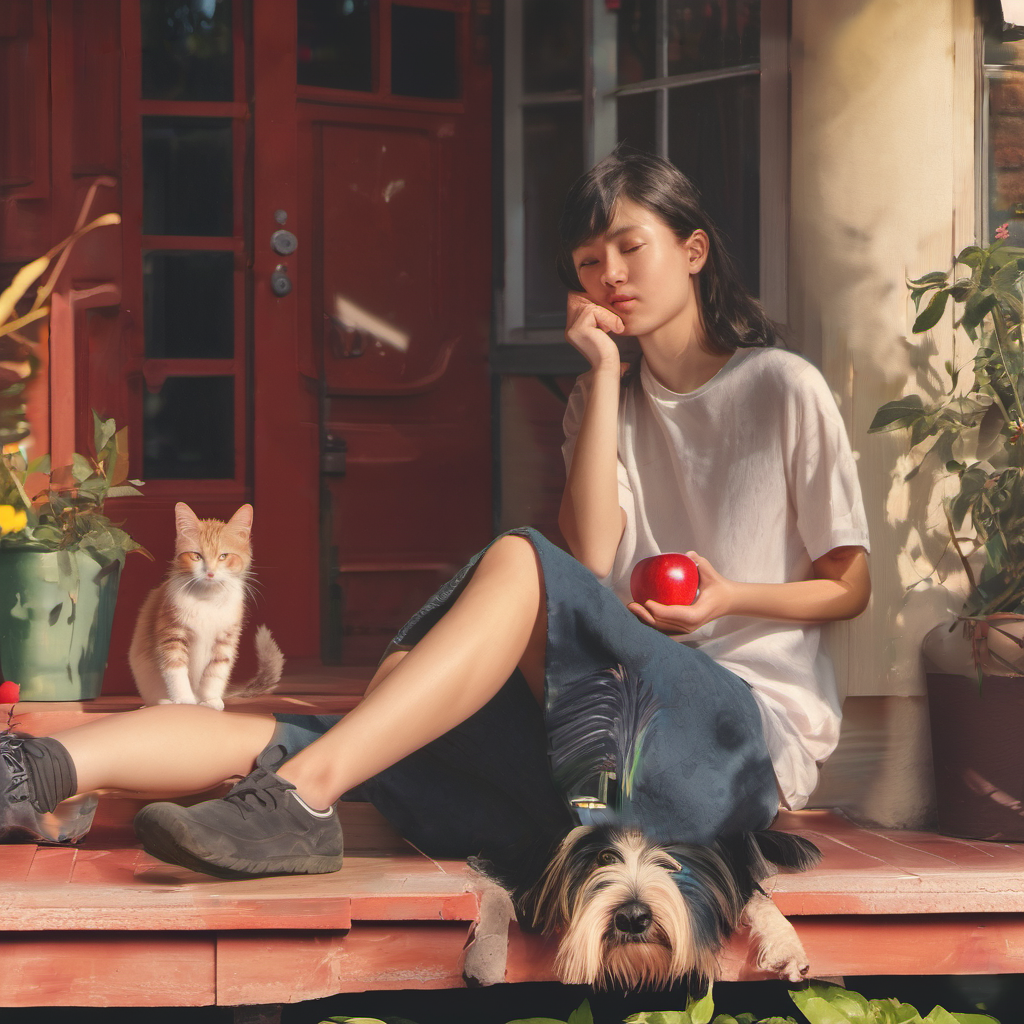

In [3]:
generator = torch.Generator(device=device).manual_seed(322)
prompt = "A young person sits on a wooden porch in soft afternoon light, holding a red apple while a cat and a dog rests nearby."

# We generate the person, apple, and cat first, then compose the dog in a second pass.
joint_prompt = "A young person sits on a wooden porch in soft afternoon light, holding a red apple while a cat rests nearby."
joint_categories = ["person", "apple", "cat"]
compose_prompt = "A dog rests nearby."
compose_category = "dog"

imgs, cross_attn_maps, inpaint_mask = multiobj_conditional_composition(
    sdxl_pipe,
    inpaint_pipe,
    prompts_list=[joint_prompt, compose_prompt],
    categories_list=[joint_categories, compose_category],
    generator=generator,
    inpaint_generator=generator,
    keep_ratios=[0.5, 0.2],
    scale_factor=20,
    strength=0.7,
    return_img_per_stage=True,
    return_mask_and_map_per_stage=True,
)
imgs[-1]

## Visualization

### 1. Visualized Inpainting Mask (red is editable region)

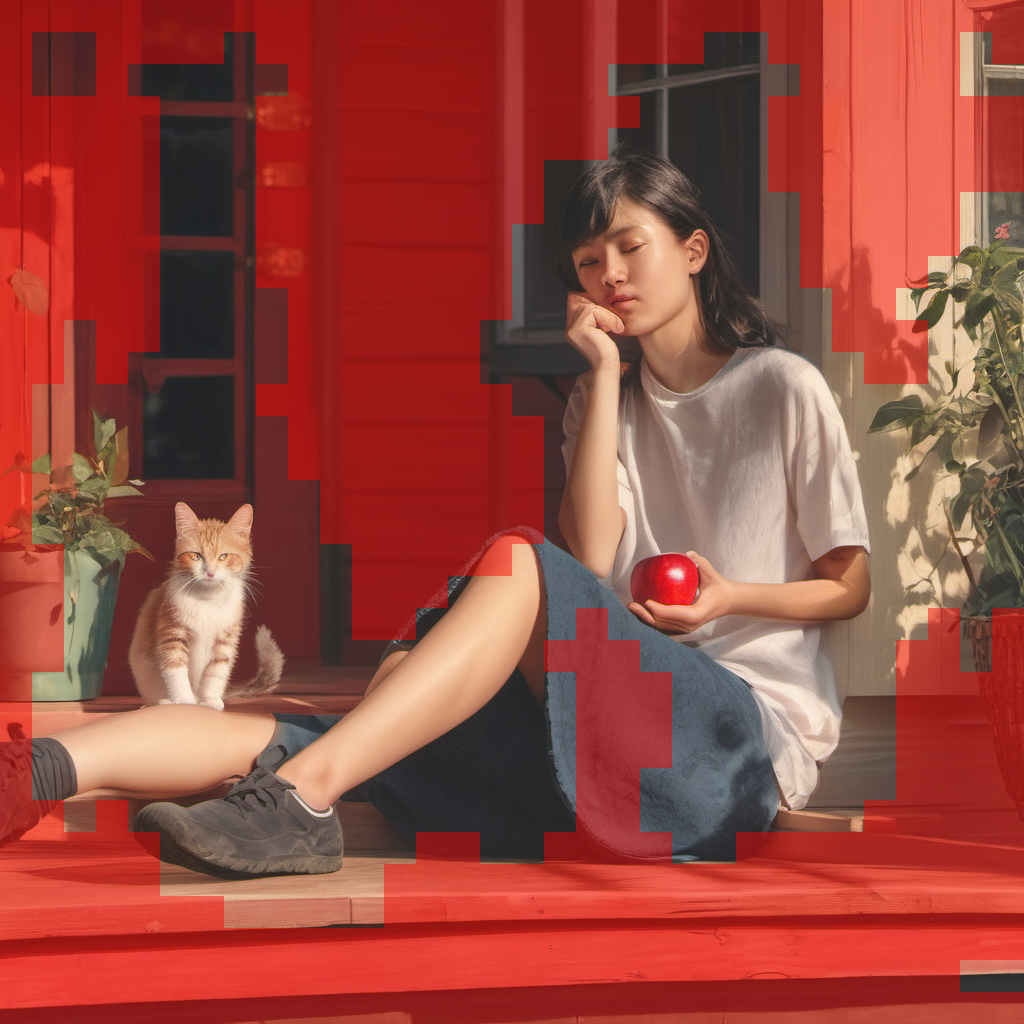

In [4]:
import torch.nn.functional as F
import numpy as np
from PIL import Image


def plot_mask(mask, save_path="layout_mask.png"):
    """
    mask: torch.Tensor of shape [B, H, W]
    """
    import matplotlib.pyplot as plt

    mask_np = mask.detach().cpu().numpy()

    plt.figure(figsize=(4, 4))
    plt.imshow(mask_np, cmap="gray")
    plt.colorbar()
    plt.title(f"Attention Mask")
    plt.axis("off")
    if save_path is not None:
        plt.savefig(save_path)
    plt.close()


def overlay_mask_on_pil(img: Image.Image, mask_1024: torch.Tensor, alpha=0.45):
    """
    mask_1024: [1024,1024] or [1,1024,1024], values {0,1}
    masked pixels will be tinted.
    """
    if mask_1024.ndim == 3:
        mask_1024 = mask_1024[0]
    m = mask_1024.detach().cpu().numpy().astype(np.float32)  # 0/1

    # FIX: align mask with PIL image coordinates
    # m = np.flipud(m)

    img_np = np.array(img).astype(np.float32)

    # red tint where mask==1 (change color if you like)
    tint = np.zeros_like(img_np)
    tint[..., 0] = 255

    out = img_np * (1 - alpha * m[..., None]) + tint * (alpha * m[..., None])
    out = np.clip(out, 0, 255).astype(np.uint8)

    return Image.fromarray(out)


mask = inpaint_mask[-1]
mask = mask.float()  # (B,1,H,W)
upsampled_mask = F.interpolate(
    mask[None, None, :, :],
    size=(1024, 1024),
    mode="nearest",
)
masked_img = overlay_mask_on_pil(imgs[0], upsampled_mask[0, 0])
masked_img

### 2. Visualizing Each Stage's Cross-Attention Map and Compute the Decomposition Score

Cross-attention maps for the joint generation stage:


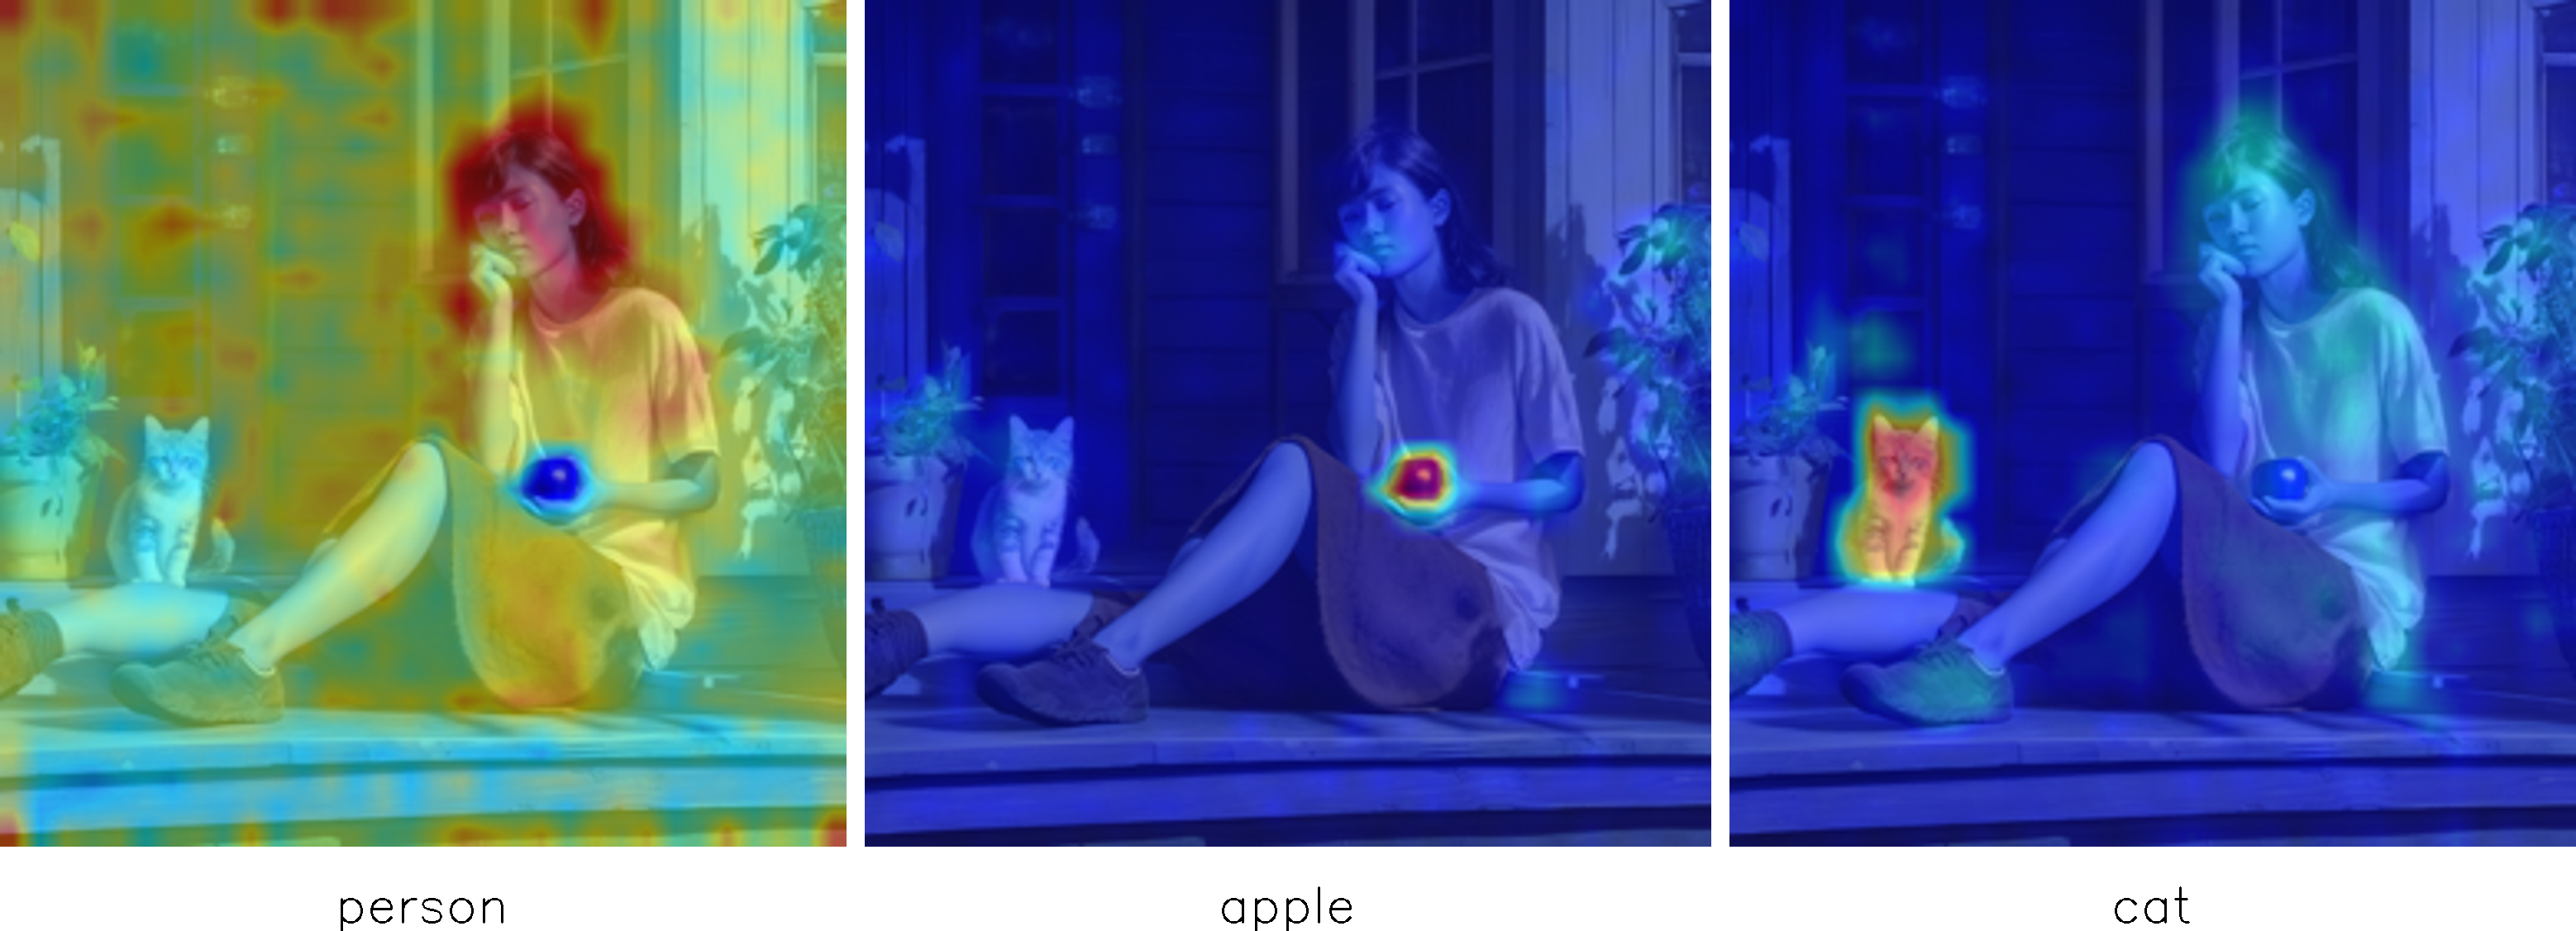

Joint Score: 0.8169

Cross-attention maps for the compose generation stage:


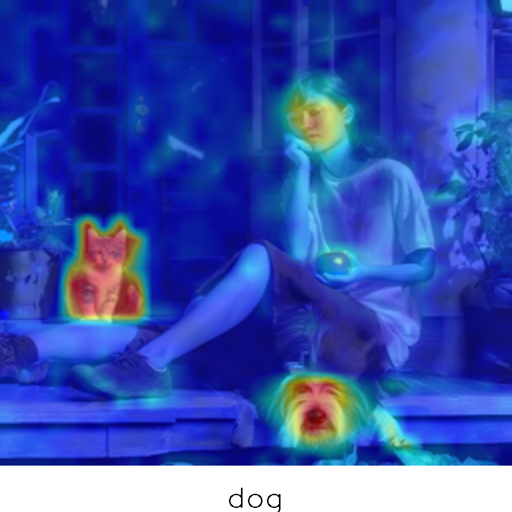

Composition Score: 0.3052

s_dog: 0.2493


In [5]:
from utils import show_cross_attention
from utils import get_category_token_indices, get_tok2id_map
from decomposition import compute_joint_score, compute_composition_score

joint_tok_map = get_tok2id_map(sdxl_pipe, joint_prompt)
joint_cross_maps = show_cross_attention(
    prompt=joint_prompt,
    attention_maps=cross_attn_maps[0],
    orig_image=imgs[0],
    indices_to_alter=get_category_token_indices(
        category=joint_categories,
        token_map=joint_tok_map,
        tokenizer=sdxl_pipe.tokenizer,
    ),
    res=32,
    tokenizer=sdxl_pipe.tokenizer,
)
print("Cross-attention maps for the joint generation stage:")
joint_cross_maps.show()
s_joint = compute_joint_score(
    cross_attn_maps[0].to(sdxl_pipe.device),
    joint_categories,
    joint_tok_map,
    sdxl_pipe.tokenizer,
    threshold=0.5,
)
print(f"Joint Score: {s_joint:.4f}\n")

compose_tok_map = get_tok2id_map(inpaint_pipe, compose_prompt)
compose_cross_maps = show_cross_attention(
    prompt=compose_prompt,
    attention_maps=inpaint_pipe.attention_store.aggregate(where=["up", "mid"]),
    orig_image=imgs[1],
    indices_to_alter=get_category_token_indices(
        category=[compose_category],
        token_map=compose_tok_map,
        tokenizer=inpaint_pipe.tokenizer,
    ),
    res=32,
    tokenizer=inpaint_pipe.tokenizer,
)
print("Cross-attention maps for the compose generation stage:")
display(compose_cross_maps.resize((512, 512)))
s_comp = compute_composition_score(
    inpaint_mask=inpaint_mask[-1],
    new_attn_map=cross_attn_maps[1].to(sdxl_pipe.device),
    threshold=0.5,
)
print(f"Composition Score: {s_comp:.4f}\n")
print(f"s_dog: {s_joint * s_comp:.4f}")